# 05 - Inertia

## Purpose

This notebook continues a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. Notebook
01 established the coast back-EMF as a direct speed signal and fitted the
coast friction. Notebook 04 measures the friction from the drive side. This
notebook measures the remaining constant of the mechanical equation, the
inertia, and does so in units the data supports.

The motor's torque constant is unknown, so the inertia is measured as
current per unit acceleration, $J_i$, in amperes per (wiper V/s$^2$). With
it the mechanical equation reads

$$J_i\,\dot\omega = i - i_c\,\mathrm{sign}(\omega) - i_v\,\omega ,$$

where $i$ is the winding current, $\omega$ the output speed in wiper V/s,
and $i_c$, $i_v$ the Coulomb and viscous friction in current units. Every
term is measured. Nothing in it needs the torque constant or the gear
ratio.

This notebook has three jobs:

1. Measure $J_i$ from the rise curve, the speed reached after drive steps
   of five lengths, by integrating the equation over each step with the
   measured current (route A, section 5).
2. Measure $J_i$ a second way, from the coast deceleration of notebook 01
   and the drive-side friction line, and compare (route B, section 6).
3. Establish the repeatability of every estimate across five recordings
   and show which speed signal makes the measurement work (section 7).

The dataset is one test session on a laptop USB port, captured on the
current measurement chain (chain 3 in notebook 00). Five step recordings,
the five spin-down recordings of notebook 01, and the ten duty-grid
recordings of notebooks 00 and 04 for the friction line. An earlier run of
all three campaigns on a 2-cell battery and the previous chain is retired
and is not a fit input anywhere below. Both the chain and the supply
changed between the two runs, so where an old number is quoted for
comparison I say which of the two could have moved it.

## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain is the
one described in notebooks 00 and 01 (chain 3), summarized here with what
this notebook needs.

- A brushed DC motor driven by an H-bridge with 20 kHz PWM, center
  aligned, under slow decay throughout this notebook. **Drive** connects
  the supply across the motor. The OFF portion of each period is **brake**,
  the winding shorted through the two low-side switches. **Coast** turns
  every switch off, so both terminals float.
- A gear train couples the motor to the output shaft. A potentiometer on
  the output shaft is read by the MCU's 12-bit ADC. Position stays in
  wiper volts, speed in wiper V/s, acceleration in wiper V/s$^2$.
- A 60 mOhm shunt resistor in the motor return path, amplified with gain
  15.0, gives the motor current channel. Current crosses the shunt only
  while the bridge drives. In brake it recirculates through the low-side
  switches, so the crest-scan sample of a slow-decay period reads the
  winding current in the drive window.
- Both motor terminals are read through 6.8 kOhm / 3.3 kOhm resistor
  dividers, channels `vmotor_a` and `vmotor_b`, with the bottom leg of each
  divider returned to a bias node $V_B$ of about 0.63 V, so that a terminal
  as low as about -1.3 V stays readable. Each tap has a 150 pF reservoir
  capacitor so the ADC's sample capacitor can charge quickly from a divider
  of a few kOhm. During coast the difference of the two terminals is the
  back-EMF (notebook 01, section 6.1).
- The ADC, clocked at 48 MHz, runs two seven-channel scans per 50 us
  period, at the crest and trough of the PWM counter. Under slow decay the
  crest scan sees the drive state. The controller streams one frame per
  period with a CRC, and corrupted frames become missing samples (verified
  in section 4).

**The board is a hacked rig.** The board under this session is a
development board that has been reworked by hand several times (the shunt,
the dividers, the bias return, the reservoir capacitors, a repaired
amplifier pad). I know of one defect on it that the next board revision
does not have. The bus telemetry stream couples into the current
amplifier's output, so a shunt sample taken while a frame is going out on
the wire can read a few counts off. On the scan geometry of this firmware
build it does not show at rest (notebook 00, section 5.2, bins the rest
current by position inside the frame and finds it flat within a count),
but one count is 0.9 mA on this chain, so a few counts is a few
milliamps, and the friction line of section 5.3 lives on currents of 30 to
70 mA. That is enough to move a low-current fit by a few percent. It is a
known limitation of this board, and I do not code around it anywhere in
this notebook.

Power is a laptop USB port. The rail reaching the motor is read at the
driven terminal in section 3. It is about 4.55 V during the long steps and
sags to about 4.47 V during the short ones, where the current is higher.
The retired battery run sat at about 7.3 V, flat, so every speed, every EMF and
every current in this notebook is smaller than in that run for the supply
alone, before any chain difference.

## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
per chain, the same table as notebooks 00 and 01. The shunt, the divider
legs, the amplifier gain, and VDD are written into every sweep's
`meta.json` by the capture tool (the `sense` block), and the loader in
section 3 checks each sweep against this table and against the supply, and
stops with an error if they disagree. The bias divider, the reservoir
capacitor, and the sampling floors are not in the metadata, so this table
is the only record of them. Every recording in this notebook is on chain 3.
Chain 2 stays in the table as the record of what the retired battery run
was captured on.

| Quantity | Chain 3 (this dataset) | Chain 2 (retired battery run) |
|---|---|---|
| ADC resolution | 12 bit (0..4095 counts) | same |
| ADC reference | VDD, nominal 3.300 V | same |
| ADC clock | 48 MHz | slower, not recorded here |
| Motor terminal divider | 6.8 kOhm top / 3.3 kOhm bottom, bottom leg returned to the terminal bias | 20 kOhm / 10 kOhm, same return |
| Terminal tap reservoir | 150 pF per tap | none |
| Terminal bias $V_B$, nominal | 200 Ohm / 47 Ohm from VDD, 0.628 V | 430 Ohm / 100 Ohm from VDD, 0.623 V |
| Terminal bias $V_B$, measured | per sweep and per terminal, from the segment-0 baseline (section 3) | per sweep |
| Current shunt | 60 mOhm | 33 mOhm |
| Current amplifier gain | 15.0 | 15.0 |
| Control period | 50 us (20 kHz) | same |
| PWM counter | 1200 timer ticks per half period, center aligned | same |
| Duty encoding | signed, 32767 = 100% | same |
| Current sampling floor | 160 timer ticks = 13.3% duty | 160 ticks = 13.3% |
| Voltage sampling floor | 120 timer ticks = 10.0% duty | 210 ticks = 17.5% |

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{r} + \frac{r - 1}{r} V_B, \qquad V_t = r\,\text{tap} - (r - 1)\, V_B, \qquad r = \frac{R_\text{top} + R_\text{bot}}{R_\text{bot}} .$$

The divider ratio $r$ is 3.06 on chain 3 and exactly 3 on chain 2. With
the bridge off and no current, both taps read $V_B$ exactly, which is how
the bias is measured per sweep (section 3). On chain 3 the two taps do not
read the same bias at rest. They differ by 18 counts in every sweep of
every recording, and notebook 00 (section 5.3) leaves the cause open. So
every absolute terminal voltage below uses the second form with the rest
reading of its own terminal in its own sweep, which absorbs the split as
an offset, and the difference $v_A - v_B$ then reads zero at rest.

All drive steps in this notebook are at 30% duty, above both sampling
floors, so every crest-scan current and terminal sample of a drive step is
settled.

Two derived units are specific to this notebook. Speed in wiper V/s comes
from the coast EMF through the slope $k_e$ in V per wiper V/s, remeasured
in section 5.1. The inertia $J_i$ is in A per (wiper V/s$^2$), and the
friction constants $i_c$ and $i_v$ in A and A per (wiper V/s). The
mechanical time constant $J_i / i_v$ is in seconds, since the units of
$\omega$ cancel.

Two caveats carry over from notebook 00. The ADC reference is the design
value, so every voltage and current scales with the true VDD of this unit.
The divider, shunt and gain are design values with unmeasured tolerances.

The derived conversion factors, per chain:

In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, curve_fit

# --- constants shared by both chains ---
ADC_COUNTS = 4096           # 12-bit converter
TICK_HZ = 20_000            # control / sample rate
PWM_HALF_TICKS = 1200       # timer ticks per PWM half period
Q15 = 32767                 # duty full scale as encoded on the wire

# --- per-chain constants (the table above) ---
# shunt/divider/gain/vdd are cross-checked against meta.json `sense`;
# bias divider and floors exist only here.
CHAIN_TABLE = {
    3: dict(label="chain 3", shunt_mohm=60, div_top=6_800, div_bot=3_300,
            gain_milli=15_000, vdd_mv=3_300, bias_top=200, bias_bot=47,
            floor_i_ticks=160, floor_v_ticks=120),
    2: dict(label="chain 2, retired", shunt_mohm=33, div_top=20_000, div_bot=10_000,
            gain_milli=15_000, vdd_mv=3_300, bias_top=430, bias_bot=100,
            floor_i_ticks=160, floor_v_ticks=210),
}
# which chain each campaign folder was captured on, and the supply it ran on
CAMPAIGN_CHAIN = {"stepcoast-usb": 3, "bridge-usb": 3, "usb": 3}
SUPPLY = "usb"

class Chain:
    # Conversion factors for one measurement chain.
    def __init__(self, n):
        c = CHAIN_TABLE[n]
        self.n, self.label = n, c["label"]
        self.vdd_v = c["vdd_mv"] / 1e3
        self.v_adc_per_count = self.vdd_v / ADC_COUNTS                  # volts at the ADC pin
        self.div_ratio = (c["div_top"] + c["div_bot"]) / c["div_bot"]  # r in the tap formula
        self.v_term_per_count = self.v_adc_per_count * self.div_ratio  # terminal volts per tap count
        self.vb_nom_v = self.vdd_v * c["bias_bot"] / (c["bias_top"] + c["bias_bot"])
        self.shunt_ohm = c["shunt_mohm"] / 1e3
        self.amp_gain = c["gain_milli"] / 1e3
        self.a_per_count = self.v_adc_per_count / (self.amp_gain * self.shunt_ohm)
        self.floor_i_pct = c["floor_i_ticks"] * 100.0 / PWM_HALF_TICKS
        self.floor_v_pct = c["floor_v_ticks"] * 100.0 / PWM_HALF_TICKS
        self.sense = {"shunt_r_mohm": c["shunt_mohm"], "vmotor_div_top": c["div_top"],
                      "vmotor_div_bot": c["div_bot"], "gain_milli": c["gain_milli"],
                      "vdd_mv": c["vdd_mv"]}

    def check_meta(self, meta, where):
        # Fail loudly if a recording was captured on different parts than
        # this table says. The keys are the capture tool's `sense` block.
        got = {k: meta["sense"][k] for k in self.sense}
        if got != self.sense:
            raise ValueError(f"{where}: meta.json sense {got} != {self.label} table {self.sense}")
        if meta["supply"] != SUPPLY:
            raise ValueError(f"{where}: supply {meta['supply']!r}, expected {SUPPLY!r}")

    def term_V(self, tap_counts, vb_counts):
        # Absolute terminal voltage from a tap reading: Vt = r tap - (r-1) VB.
        return (self.div_ratio * tap_counts - (self.div_ratio - 1) * vb_counts) * self.v_adc_per_count

CHAINS = {n: Chain(n) for n in CHAIN_TABLE}
CH = CHAINS[CAMPAIGN_CHAIN["stepcoast-usb"]]   # every number in this notebook is on this chain
DT = 1.0 / TICK_HZ

def term_V(tap_counts, vb_counts):
    # Shorthand for the chain of this notebook.
    return CH.term_V(tap_counts, vb_counts)

rows = []
for ch in CHAINS.values():
    rows += [
        {"chain": ch.label, "quantity": "pot wiper", "value": ch.v_adc_per_count * 1e3, "unit": "mV per count"},
        {"chain": ch.label, "quantity": "terminal divider ratio r", "value": ch.div_ratio, "unit": ""},
        {"chain": ch.label, "quantity": "motor terminal difference", "value": ch.v_term_per_count * 1e3, "unit": "mV per count"},
        {"chain": ch.label, "quantity": "terminal bias, nominal", "value": ch.vb_nom_v * 1e3, "unit": "mV"},
        {"chain": ch.label, "quantity": "motor current", "value": ch.a_per_count * 1e3, "unit": "mA per count"},
        {"chain": ch.label, "quantity": "drive window settled, current", "value": ch.floor_i_pct, "unit": "% duty and above"},
        {"chain": ch.label, "quantity": "drive window settled, voltage", "value": ch.floor_v_pct, "unit": "% duty and above"},
    ]
pd.DataFrame(rows).set_index(["quantity", "unit", "chain"])["value"].unstack("chain").round(4)

,chain,"chain 2, retired",chain 3
quantity,unit,,
"drive window settled, current",% duty and above,13.3333,13.3333
"drive window settled, voltage",% duty and above,17.5000,10.0000
motor current,mA per count,1.6276,0.8952
motor terminal difference,mV per count,2.4170,2.4658
pot wiper,mV per count,0.8057,0.8057
"terminal bias, nominal",mV,622.6415,627.9352
terminal divider ratio r,,3.0000,3.0606


## 3. Capture method

Three campaigns enter this notebook, all under `notebooks/telemetry/sg90/`
and all on chain 3 at USB.

- **Step series** (`stepcoast-usb/`, five recordings). Each recording holds
  five sweeps, one per step length of 20, 40, 60, 80 and 120 ms, captured
  back to back. Each sweep has five segments. Segment 0 is a one-second
  baseline with the bridge disabled. Segment 1 is a forward drive step at
  30% duty of the named length. Segment 2 is 300 ms of coast. Segments 3
  and 4 repeat the pair in reverse. The coast segments start when the
  drive command ends, so the motor enters them at the speed the step
  reached.
- **Spin-down series** (`bridge-usb/`, the five recordings of notebook 01).
  The spin-down sweep of each recording holds 80 ms drive steps at 20%,
  30% and 40% duty, each followed by 400 ms of coast or brake, forward
  then reverse. Its coast segments give the EMF-to-speed slope and the
  coast friction. The slow-decay sweep of the same recording gives the
  rail.
- **Duty grid** (`usb/`, the ten recordings of notebooks 00 and 04). 80 ms
  slow-decay drive steps at 5% to 100% duty in 5% increments, forward then
  reverse. They give the drive-side friction line of section 5.3.

Before every drive step the servo is repositioned at 15% duty toward the
far end of travel, so the step has room to accelerate. The mechanism is
still moving from that repositioning move when the step begins, in the
direction opposite to the step, so every step starts from a negative,
unknown speed. Section 5.3 treats that entry speed as a fitted parameter
and section 7 shows why the pot cannot supply it.

**Data acceptance.** A recording is accepted only if the host counted zero
dropped frames in all its sweeps. Section 4 re-verifies this from the
data itself.

Each row of a sweep is one 50 us sample with the segment number, the
commanded duty, the direction, the tick counter, the firmware's validity
flag, the position, the crest-scan shunt (`current_raw`), the trough-scan
shunt (`current_trough`), and the crest-scan terminals (`vmotor_a`,
`vmotor_b`).

The segment-0 baseline of every sweep gives three per-sweep constants, the
shunt amplifier's bias (mean of `current_raw`) and the rest reading of
each terminal (median of `vmotor_a` and of `vmotor_b`), which are the
$V_B$ of terminal A and of terminal B in the tap formula. The loader also
checks each sweep's `sense` block and supply against section 2. The rail
of a step sweep is the median driven terminal over the valid samples of
its two drive steps, each direction read on its own terminal with that
terminal's own rest reading. The table lists both rest readings per
recording, their split, how much each one moves across the five sweeps of
a recording, and the rail of the shortest and the longest sweep.

In [2]:
TELEMETRY = Path("telemetry/sg90")
STEP_MS = (20, 40, 60, 80, 120)

def by_number(paths):
    return sorted(paths, key=lambda p: int(p.name.split("-")[1]))

def load_sweep(path, name):
    # One sweep = <name>.csv.gz (per-tick samples) + its meta.json. Derived
    # columns: duty_pct (signed percent), mag_pct (rounded magnitude), and the
    # per-sweep baseline constants bias (shunt amplifier offset), vb (terminal
    # A rest reading), vb_b (terminal B rest reading).
    df = pd.read_csv(path / f"{name}.csv.gz")
    meta_name = "meta.json" if name == "sweep" else f"{name}.meta.json"
    meta = json.loads((path / meta_name).read_text())
    CH.check_meta(meta, f"{path}/{name}")
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    if "schedule" in meta and any(":" in s for s in meta["schedule"]):
        sched = meta["schedule"]
        kinds = ["baseline"] + [
            "drive" if ":" not in s else s.split(":")[0]
            for s in sched * (df["seg"].max() // len(sched))
        ]
        df["kind"] = df["seg"].map(dict(enumerate(kinds)))
    return df, meta

def rail_V(df):
    # Median driven terminal over the valid drive samples at 20% duty and
    # above, each direction read on its own terminal with that terminal's
    # own rest reading, then averaged.
    v = df[(df["seg"] > 0) & (df["window_valid"] == 1) & (df["mag_pct"] >= 20)]
    vals = []
    for sel, col, vb in ((v["duty_pct"] > 0, "vmotor_a", "vb"), (v["duty_pct"] < 0, "vmotor_b", "vb_b")):
        if sel.any():
            vals.append(CH.term_V(np.median(v.loc[sel, col]), df[vb].iloc[0]))
    return float(np.mean(vals))

steps_raw = {d.name: {ms: load_sweep(d, f"step{ms}") for ms in STEP_MS}
             for d in by_number((TELEMETRY / "stepcoast-usb").glob("capture-*"))}
spin_raw = {d.name: {name: load_sweep(d, name) for name in ("slow", "spindown")}
            for d in by_number((TELEMETRY / "bridge-usb").glob("capture-*"))}
grid_raw = {d.name: load_sweep(d, "sweep")[0]
            for d in by_number((TELEMETRY / "usb").glob("capture-*"))}

rows = []
for name, sweeps in steps_raw.items():
    a = [sweeps[ms][0]["vb"].iloc[0] for ms in STEP_MS]
    b = [sweeps[ms][0]["vb_b"].iloc[0] for ms in STEP_MS]
    rails = [rail_V(sweeps[ms][0]) for ms in STEP_MS]
    rows.append({
        "recording": name,
        "VB_A [counts]": a[0],
        "VB_B [counts]": b[0],
        "B minus A [counts]": b[0] - a[0],
        "A spread over sweeps [counts]": max(a) - min(a),
        "B spread over sweeps [counts]": max(b) - min(b),
        "VB_A minus nominal [mV]": (a[0] * CH.v_adc_per_count - CH.vb_nom_v) * 1e3,
        "rail, 20 ms sweep [V]": rails[0],
        "rail, 120 ms sweep [V]": rails[-1],
    })
pd.DataFrame(rows).set_index("recording").round(3)

,VB_A [counts],VB_B [counts],B minus A [counts],A spread over sweeps [counts],B spread over sweeps [counts],VB_A minus nominal [mV],"rail, 20 ms sweep [V]","rail, 120 ms sweep [V]"
recording,,,,,,,,
capture-1,766.0,784.0,18.0,0.0,0.0,-10.797,4.474,4.551
capture-2,766.0,784.0,18.0,0.0,0.0,-10.797,4.469,4.551
capture-3,766.0,784.0,18.0,1.0,0.0,-10.797,4.474,4.551
capture-4,766.0,784.0,18.0,0.0,0.0,-10.797,4.467,4.550
capture-5,766.0,784.0,18.0,0.0,0.0,-10.797,4.471,4.551


Terminal A rests at 766 counts and terminal B at 784 in every recording,
an 18-count split that does not move across the five sweeps of a
recording. Terminal A sits 10.8 mV below the nominal bias.

The rail read during the 20 ms steps is 0.08 V below the rail read during
the 120 ms steps of the same recording, because the current is higher in
the short steps (section 5.2) and the USB supply's source resistance takes
the difference. This sag within a recording is new. The retired battery
run held its rail flat, and the same 0.08 V there came from the battery's
internal resistance at twice the current. The rail enters this notebook
only as the discriminator threshold of the coast window.

## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every sweep from the tick column,
which increments by one per sample within a segment, summed over the
sweeps of each recording.

In [3]:
def missing_samples(df):
    missing = 0
    for _, seg in df.groupby("seg"):
        ticks = seg["tick"].to_numpy()
        missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
    return missing

rows = []
for name, sweeps in steps_raw.items():
    dfs = [sweeps[ms][0] for ms in STEP_MS]
    rows.append({"campaign": "step series", "recording": name, "sweeps": len(dfs),
                 "samples": sum(len(d) for d in dfs), "segments": sum(d["seg"].nunique() for d in dfs),
                 "missing_samples": sum(missing_samples(d) for d in dfs)})
for name, sweeps in spin_raw.items():
    dfs = [sweeps[k][0] for k in ("slow", "spindown")]
    rows.append({"campaign": "spin-down series", "recording": name, "sweeps": len(dfs),
                 "samples": sum(len(d) for d in dfs), "segments": sum(d["seg"].nunique() for d in dfs),
                 "missing_samples": sum(missing_samples(d) for d in dfs)})
for name, df in grid_raw.items():
    rows.append({"campaign": "duty grid", "recording": name, "sweeps": 1,
                 "samples": len(df), "segments": df["seg"].nunique(),
                 "missing_samples": missing_samples(df)})
pd.DataFrame(rows).set_index(["campaign", "recording"])

sweeps  samples  segments  missing_samples
campaign         recording                                             
step series      capture-1        5   172800        25                0
                 capture-2        5   172800        25                0
                 capture-3        5   172800        25                0
                 capture-4        5   172800        25                0
                 capture-5        5   172800        25                0
spin-down series capture-1        2   219200        66                0
                 capture-2        2   219200        66                0
                 capture-3        2   219200        66                0
                 capture-4        2   219200        66                0
                 capture-5        2   219200        66                0
duty grid        capture-1        1    84000        41                0
                 capture-2        1    84000        41                0
                 capture-3        1    84000        41                0
                 capture-4        1    84000        41                0
                 capture-5        1    84000        41                0
                 capture-6        1    84000        41                0
                 capture-7        1    84000        41                0
                 capture-8        1    84000        41                0
                 capture-9        1    84000        41                0
                 capture-10       1    84000        41                0

Every sweep of every recording has zero missing samples.

## 5. The rise curve

### 5.1 Coast-entry EMF and speed against step length

The speed at the end of a drive step is read from the back-EMF in the
first milliseconds of the coast that follows. Notebook 01 established the
method. During coast the difference of the two terminals is the EMF,
$e = r\,(\text{tap}_A - \text{tap}_B)$ less the rest split, taken positive
along the drive direction. The first three coast samples are excluded. The
first one still reads the drive rail, and the next one or two are taken
while the bridge is still switching and can read anywhere from -3.1 V to
the rail on the terminal difference. From the third sample on the lowest
reading in this dataset is 0.23 V, so the coast entry is taken from the
third sample onward and never from the first two. Any later sample whose
terminal sum exceeds the rail is dropped as well (the winding current is
still dying through the body diodes there). The EMF is linear in speed
with a slope $k_e$ measured from the spin-down coasts, where the pot's
travel over a whole segment calibrates the EMF's integral.

The slope and the coast friction are recomputed here from the spin-down
recordings, with the fit of notebook 01 (section 6.2 there). The model is
$\dot v = -(a + b\,v)$ for $v > 0$, fitted jointly to the EMF traces of
the six coast segments of a recording with one $(a, b)$ per recording and
one entry value per segment, and also to the position traces (the pot
route). The terminal-route $a$ is converted to wiper units with the
recording's own slope.

In [4]:
SKIP = 3       # coast samples excluded at the start of every coast segment
FIT_N = 5000   # 250 ms of every coast segment enters the friction fit

def coast_segments(sp, rail):
    # Per coast segment: position and EMF along the entry direction, the
    # terminal sum, and the sample mask of notebook 01.
    out = []
    for seg_id, seg in sp[sp["kind"] == "coast"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        vb, vb_b = seg["vb"].iloc[0], seg["vb_b"].iloc[0]
        vA, vB = term_V(seg["vmotor_a"].to_numpy(), vb), term_V(seg["vmotor_b"].to_numpy(), vb_b)
        ssum = vA + vB
        out.append({
            "seg": seg_id, "dir": d,
            "entry_pct": int(sp.loc[sp["seg"] == seg_id - 1, "mag_pct"].iloc[0]),
            "p": seg["pos"].to_numpy() * d * CH.v_adc_per_count,
            "e": (vA - vB) * d,
            "mask": (np.arange(len(seg)) >= SKIP) & (ssum < rail),
        })
    return out

def speed_model(t, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    return np.where(t < t_stop, (v0 + a / b) * np.exp(-b * np.minimum(t, t_stop)) - a / b, 0.0)

def traj(t, p0, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    tt = np.minimum(t, t_stop)
    return p0 + (v0 + a / b) * (1 - np.exp(-b * tt)) / b - (a / b) * tt

def joint_fit(segs, signal, use_mask, has_p0):
    # Shared (a, b), per-segment start value (and offset when has_p0).
    t = np.arange(FIT_N) * DT
    per = 2 if has_p0 else 1
    def resid(x):
        r = []
        for i, c in enumerate(segs):
            y = c[signal][:FIT_N]
            m = c["mask"][:FIT_N] if use_mask else np.ones(len(y), bool)
            if has_p0:
                model = traj(t, x[2 + per * i], x[3 + per * i], x[0], x[1])
            else:
                model = speed_model(t, x[2 + i], x[0], x[1])
            r.append((model - y)[m])
        return np.concatenate(r)
    x0, lb = [30.0, 5.0], [0.0, 0.0]
    for c in segs:
        y = c[signal]
        if has_p0:
            x0 += [y[0], 5.0]
            lb += [-np.inf, 0.0]
        else:
            x0 += [max(y[3], 0.1)]
            lb += [0.0]
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    return {"a": res.x[0], "b": res.x[1], "rms": np.sqrt(np.mean(res.fun ** 2))}

rows = []
for name, sweeps in spin_raw.items():
    sp = sweeps["spindown"][0]
    segs = coast_segments(sp, rail_V(sweeps["slow"][0]))
    ratios = []
    for c in segs:
        travel = np.median(c["p"][-1000:]) - np.median(c["p"][:3])
        ratios.append(np.sum(c["e"][c["mask"]]) * DT / travel)
    slope = np.mean(ratios)
    term = joint_fit(segs, "e", True, False)
    pot = joint_fit(segs, "p", False, True)
    rows.append({
        "recording": name,
        "k_e [V per wiper V/s]": slope,
        "a, terminal route [wiper V/s2]": term["a"] / slope,
        "b, terminal route [1/s]": term["b"],
        "a/b, terminal route [wiper V/s]": term["a"] / slope / term["b"],
        "a, pot route [wiper V/s2]": pot["a"],
        "b, pot route [1/s]": pot["b"],
    })
coast_tab = pd.DataFrame(rows).set_index("recording")
K_E = coast_tab["k_e [V per wiper V/s]"].mean()
A_COAST = coast_tab["a, terminal route [wiper V/s2]"]
B_COAST = coast_tab["b, terminal route [1/s]"]

def with_summary(tab):
    s = tab.agg(["mean", "min", "max"])
    s.loc["cv [%]"] = tab.std() / tab.mean().abs() * 100
    if isinstance(tab.index, pd.MultiIndex):
        s.index = pd.MultiIndex.from_tuples([(k, "") for k in s.index], names=tab.index.names)
    return pd.concat([tab, s])

with_summary(coast_tab).round(3)

,k_e [V per wiper V/s],"a, terminal route [wiper V/s2]","b, terminal route [1/s]","a/b, terminal route [wiper V/s]","a, pot route [wiper V/s2]","b, pot route [1/s]"
capture-1,0.271,31.771,4.432,7.168,41.738,0.001
capture-2,0.278,31.985,4.224,7.571,42.137,0.003
capture-3,0.278,30.678,4.577,6.703,36.696,2.936
capture-4,0.278,31.328,4.380,7.153,40.389,0.009
capture-5,0.276,30.983,4.565,6.787,41.084,0.003
mean,0.276,31.349,4.436,7.076,40.409,0.590
min,0.271,30.678,4.224,6.703,36.696,0.001
max,0.278,31.985,4.577,7.571,42.137,2.936
cv [%],1.075,1.723,3.276,4.909,5.392,222.141


The slope is 0.276 V per wiper V/s on average (0.271 to 0.278 across
recordings), the value used for every EMF-to-speed conversion below. It is
4% below the 0.287 the retired battery run gave. The coast friction is
31.3 wiper V/s$^2$ Coulomb (30.7 to 32.0) and 4.44 1/s viscous (4.22 to
4.58) by the terminal route, with a ratio $a/b$ of 7.08 wiper V/s. The pot
route puts the Coulomb term at 40.4 and cannot resolve the viscous term
(0.0 to 2.9 1/s), as in notebook 01. The coast entry speeds of these
segments run 1.6 to 4.9 wiper V/s, about half the range the battery run
reached, which is what section 5.3 matches the friction line to.

The step series is read the same way. For every drive step the coast-entry
EMF is the mean of coast samples 3 to 23 (0.15 to 1.15 ms after the drive
ends) that pass the mask, and the speed at the end of the step is that EMF
divided by $k_e$. The figure shows the EMF against step length for every
recording and both directions, and the first 3 ms of the coast EMF of one
recording, where the averaging window sits.

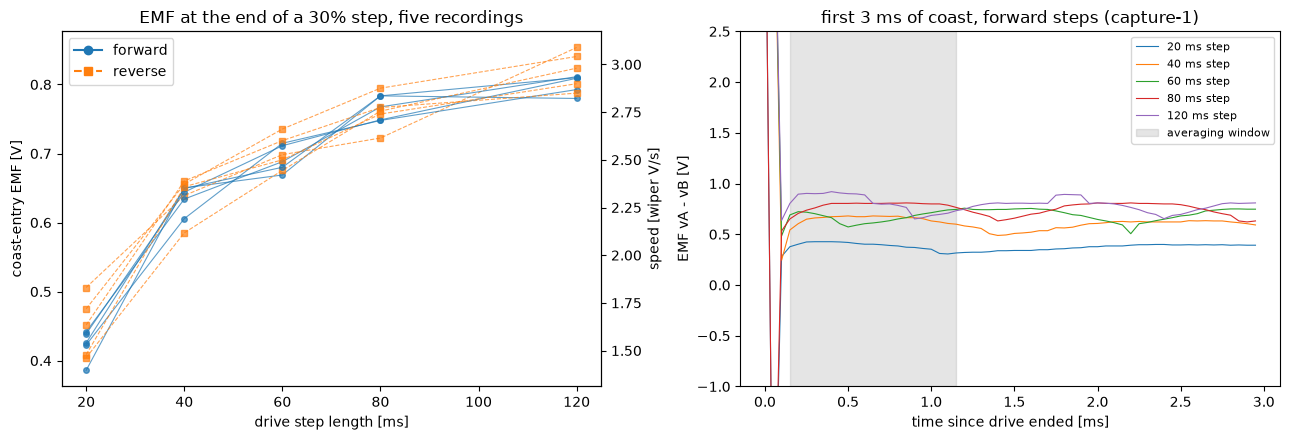

emf_V  emf_spread_pct  emf_sd_within_V  samples  omega_T  \
direction step_ms                                                             
forward   20       0.423           5.266            0.037     21.0    1.530   
          40       0.637           2.909            0.042     21.0    2.304   
          60       0.693           2.871            0.060     21.0    2.506   
          80       0.766           2.297            0.051     21.0    2.773   
          120      0.800           1.731            0.071     21.0    2.897   
reverse   20       0.449           9.683            0.030     21.0    1.625   
          40       0.638           4.828            0.042     21.0    2.310   
          60       0.704           3.345            0.058     21.0    2.547   
          80       0.760           3.394            0.069     21.0    2.752   
          120      0.821           3.318            0.076     21.0    2.972   

                   travel_V  
direction step_ms            
forward   20          0.006  
          40          0.061  
          60          0.109  
          80          0.157  
          120         0.256  
reverse   20          0.005  
          40          0.073  
          60          0.088  
          80          0.149  
          120         0.277

In [5]:
ENTRY_LO, ENTRY_HI = 3, 23   # coast samples averaged for the coast-entry EMF

def step_records(name, sweeps):
    out = []
    for ms in STEP_MS:
        df = sweeps[ms][0]
        vb, vb_b = df["vb"].iloc[0], df["vb_b"].iloc[0]
        bias, rail = df["bias"].iloc[0], rail_V(df)
        for s in (1, 3):
            drv, co = df[df["seg"] == s], df[df["seg"] == s + 1]
            d = int(drv["dir"].iloc[0])
            vA, vB = term_V(co["vmotor_a"].to_numpy(), vb), term_V(co["vmotor_b"].to_numpy(), vb_b)
            e = (vA - vB) * d
            k = np.arange(len(e))
            sel = (k >= ENTRY_LO) & (k <= ENTRY_HI) & (vA + vB < rail)
            cur = (drv["current_raw"].to_numpy() - bias) * CH.a_per_count
            ok = drv["window_valid"].to_numpy() == 1
            cur = pd.Series(np.where(ok, cur, np.nan)).ffill().bfill().to_numpy()
            p = drv["pos"].to_numpy() * CH.v_adc_per_count * d
            t = np.arange(len(p)) * DT
            out.append({
                "recording": name, "step_ms": ms, "dir": d, "T_s": len(p) * DT,
                "emf_V": e[sel].mean(), "emf_sd_V": e[sel].std(), "emf_n": int(sel.sum()),
                "omega_T": e[sel].mean() / K_E,
                "cur": cur, "pos": p, "emf_trace": e,
                "w0_pot": np.polyfit(t[:100], p[:100], 1)[0],       # first 5 ms
                "wT_pot": np.polyfit(t[-100:], p[-100:], 1)[0],     # last 5 ms
                "travel_V": p[-1] - p[0],
            })
    return out

step_list = sum((step_records(n, s) for n, s in steps_raw.items()), [])
steps = pd.DataFrame(step_list)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, g in steps.groupby("recording"):
    for d, mk in ((1, "-o"), (-1, "--s")):
        gg = g[g["dir"] == d].sort_values("step_ms")
        axes[0].plot(gg["step_ms"], gg["emf_V"], mk, ms=4, lw=0.8, alpha=0.7,
                     color="tab:blue" if d > 0 else "tab:orange")
axes[0].plot([], [], "-o", color="tab:blue", label="forward")
axes[0].plot([], [], "--s", color="tab:orange", label="reverse")
axes[0].set_xlabel("drive step length [ms]")
axes[0].set_ylabel("coast-entry EMF [V]")
axes[0].set_title("EMF at the end of a 30% step, five recordings")
axes[0].legend()
ax2 = axes[0].twinx()
ax2.set_ylim(np.array(axes[0].get_ylim()) / K_E)
ax2.set_ylabel("speed [wiper V/s]")
first = steps[(steps["recording"] == next(iter(steps_raw))) & (steps["dir"] == 1)]
for _, row in first.sort_values("step_ms").iterrows():
    e = row["emf_trace"][:60]
    axes[1].plot(np.arange(len(e)) * DT * 1e3, e, "-", lw=0.8, label=f"{row['step_ms']} ms step")
axes[1].axvspan(ENTRY_LO * DT * 1e3, ENTRY_HI * DT * 1e3, color="grey", alpha=0.2, label="averaging window")
axes[1].set_ylim(-1, 2.5)
axes[1].set_xlabel("time since drive ended [ms]")
axes[1].set_ylabel("EMF vA - vB [V]")
axes[1].set_title(f"first 3 ms of coast, forward steps ({first['recording'].iloc[0]})")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

DIRS = {1: "forward", -1: "reverse"}
entry = steps.assign(direction=steps["dir"].map(DIRS)).groupby(["direction", "step_ms"]).agg(
    emf_V=("emf_V", "mean"), emf_spread_pct=("emf_V", lambda s: s.std() / s.mean() * 100),
    emf_sd_within_V=("emf_sd_V", "mean"), samples=("emf_n", "mean"),
    omega_T=("omega_T", "mean"), travel_V=("travel_V", "mean"))
entry.round(3)

Findings:

- The coast-entry EMF rises from 0.42 V at 20 ms to 0.80 V at 120 ms
  forward (0.45 to 0.82 V reverse), which is 1.5 to 3.0 wiper V/s. The
  rise is steep between 20 and 40 ms and nearly flat from 80 to 120 ms,
  the shape of a first-order approach to a steady speed near 3.0 wiper
  V/s, which section 5.3 fits. Both the EMF and the speed are about half
  what the battery run reached, which is the supply.
- The spread across the five recordings is under 3.5% at 40 ms and above.
  At 20 ms it is 5% forward and 10% reverse, the one step short enough for
  the entry speed to matter (section 5.3).
- The EMF in the averaging window is flat to within its ripple. The first
  sample reads the drive rail, the second and third carry the bridge
  switching, and all three are excluded by the mask.

### 5.2 Drive current during the step

The current that accelerates the motor is the per-sample crest-scan shunt
reading of the drive step, bias subtracted. The figure shows it for the
five step lengths of one recording, forward. The table summarizes the
trace by step length, pooled over recordings and directions, and fits the
tail of the 60, 80 and 120 ms steps (from 10 ms in) with a single
exponential $i(t) = i_{ss} + A\,e^{-t/\tau_i}$, the form notebook 04 uses
on the duty grid.

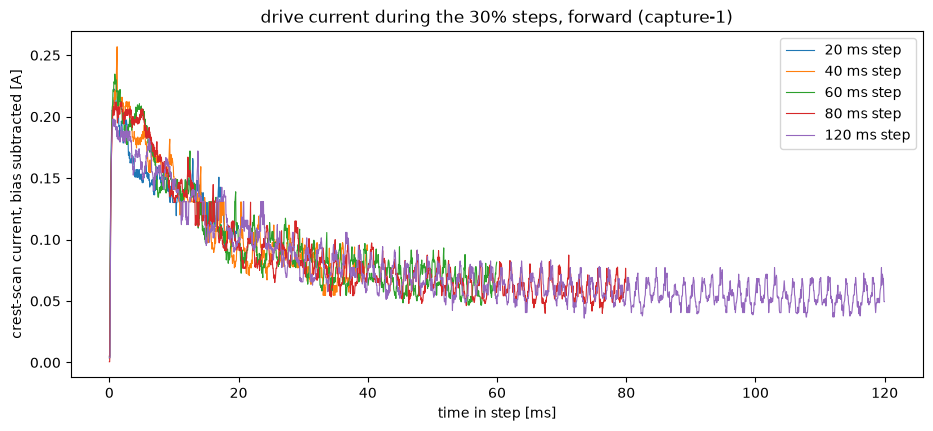

,i_at_0.5ms_A,i_peak_A,t_peak_ms,i_mean_A,i_last_2ms_A,peak_over_last,tail_i_ss_A,tail_tau_ms
step_ms,,,,,,,,
20,0.195,0.232,1.510,0.144,0.101,2.316,NaN,NaN
40,0.191,0.235,1.575,0.113,0.073,3.256,NaN,NaN
60,0.196,0.236,1.985,0.099,0.062,3.795,0.057,16.261
80,0.197,0.233,1.705,0.087,0.053,4.401,0.053,18.229
120,0.201,0.232,1.620,0.076,0.051,4.558,0.052,18.316


In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for _, row in first.sort_values("step_ms").iterrows():
    ax.plot(np.arange(len(row["cur"])) * DT * 1e3, row["cur"], lw=0.8, label=f"{row['step_ms']} ms step")
ax.set_xlabel("time in step [ms]")
ax.set_ylabel("crest-scan current, bias subtracted [A]")
ax.set_title(f"drive current during the 30% steps, forward ({first['recording'].iloc[0]})")
ax.legend()
plt.show()

def i_model(t, i_ss, A, tau):
    return i_ss + A * np.exp(-t / tau)

TAIL_SKIP = 200   # 10 ms, excluded from the exponential fit of the current tail

rows = []
for _, row in steps.iterrows():
    c = row["cur"]
    r = {"step_ms": row["step_ms"], "i_at_0.5ms_A": c[10], "i_peak_A": c.max(),
         "t_peak_ms": int(c.argmax()) * DT * 1e3, "i_mean_A": c.mean(),
         "i_last_2ms_A": c[-40:].mean(), "peak_over_last": c.max() / c[-40:].mean()}
    if row["step_ms"] >= 60:
        t = np.arange(len(c) - TAIL_SKIP) * DT
        (i_ss, A, tau), _ = curve_fit(i_model, t, c[TAIL_SKIP:], p0=[c[-1], c[TAIL_SKIP] - c[-1], 0.02])
        r.update({"tail_i_ss_A": i_ss, "tail_tau_ms": tau * 1e3})
    rows.append(r)
current_tab = pd.DataFrame(rows).groupby("step_ms").mean()
current_tab.round(3)


Findings:

- The current rises from the bias to about 0.20 A within the first 0.5 ms
  of every step, the inductive rise against the winding, and peaks at
  0.232 to 0.236 A between 1.5 and 2.0 ms. In this window the motor is
  still moving backward from the repositioning move, and its EMF adds to
  the applied voltage. The peak is 0.23 A where the battery run peaked at
  0.56 A, which is the supply and not the chain.
- From there the current falls as the motor reverses and speeds up, to
  0.10 A at the end of the 20 ms step and 0.05 A at the end of the 120 ms
  step, a factor of 2.3 to 4.6 from peak to end. The step-mean current
  falls from 0.14 A at 20 ms to 0.08 A at 120 ms. A model that drives the
  inertia with the mean current is therefore wrong by design, and section
  5.3 shows by how much.
- The tail of the long steps follows one exponential with $\tau_i$ of
  16.3 to 18.3 ms toward a floor of 0.052 to 0.057 A, the same time
  constant notebook 04 reads on the duty grid. The floor is the steady
  drive current at 30% duty, the friction current at that speed.

### 5.3 Route A, the rise curve fitted with the measured current

The equation of the purpose section is integrated over every step with
the measured current trace,

$$\omega(T) = \omega_0 + \frac{1}{J_i}\int_0^T \big(i(t) - i_c\,\mathrm{sign}\,\omega(t) - i_v\,\omega(t)\big)\,dt ,$$

by forward Euler at the sample rate, and $\omega(T)$ is matched to the
coast-entry speed of the step. The unknowns per recording are $J_i$ and
one entry speed $\omega_0$ per direction, three parameters for ten
measured speeds, on the premise that the repositioning move leaves the
mechanism at about the same speed before every step of a direction. The
fit weighs all ten speeds equally.

The friction line $i = i_c + i_v\,\omega$ per direction comes from the
duty grid with the method of notebook 04, recomputed here so the numbers
are traceable within this notebook. For each grid step at or above 15%
duty, the current after the first 10 ms is fitted with the exponential of
section 5.2 to extrapolate the steady current, and the position over the
same window is fitted with the matching first-order trajectory to
extrapolate the steady speed. The line is fitted through the steps whose
steady speed is at or below 5.0 wiper V/s, the range the coast segments
cover. That ceiling is 5.0 here where it was 10.5 on the battery run,
because the coast entries came down with the supply, and notebook 04
(section 6.1) measures how much the line moves with the range.

In [7]:
GRID_SKIP = 200     # first 10 ms of each grid step excluded from the extrapolation
V_MATCH = 5.0       # wiper V/s, the ceiling of the coast entry speeds

def grid_steps(name, df):
    out = []
    for seg_id, seg in df[(df["seg"] > 0) & (df["mag_pct"] >= 15)].groupby("seg"):
        d = np.sign(seg["duty_pct"].iloc[0])
        p = seg["pos"].to_numpy() * CH.v_adc_per_count * d
        cur = (seg["current_raw"].to_numpy() - seg["bias"].iloc[0]) * CH.a_per_count
        ok = seg["window_valid"].to_numpy() == 1
        t = np.arange(len(p) - GRID_SKIP) * DT
        c, tc = cur[GRID_SKIP:][ok[GRID_SKIP:]], t[ok[GRID_SKIP:]]
        (i_ss, A, tau), _ = curve_fit(i_model, tc, c, p0=[c[-1], c[0] - c[-1], 0.02],
                                      bounds=([0, -np.inf, 0.002], [np.inf, np.inf, 0.5]))
        g = tau * (1 - np.exp(-t / tau))
        X = np.column_stack([np.ones_like(t), t - g, g])
        p0, v_ss, v0 = np.linalg.lstsq(X, p[GRID_SKIP:], rcond=None)[0]
        out.append({"recording": name, "mag_pct": int(round(abs(seg["duty_pct"].iloc[0]))),
                    "dir": int(d), "v_ss": v_ss, "i_ss": i_ss, "tau_ms": tau * 1e3})
    return out

grid = pd.DataFrame(sum((grid_steps(n, df) for n, df in grid_raw.items()), []))
I_C, I_V = {}, {}
rows = []
for d, label in DIRS.items():
    g = grid[(grid["dir"] == d) & (grid["v_ss"] <= V_MATCH)]
    k = np.polyfit(g["v_ss"], g["i_ss"], 1)
    I_C[d], I_V[d] = k[1], k[0]
    per = np.array([np.polyfit(gg["v_ss"], gg["i_ss"], 1) for _, gg in g.groupby("recording")])
    rows.append({"direction": label, "steps": len(g), "i_c [A]": k[1], "i_v [A per wiper V/s]": k[0],
                 "i_c / i_v [wiper V/s]": k[1] / k[0],
                 "i_c per-recording cv [%]": per[:, 1].std() / per[:, 1].mean() * 100,
                 "i_v per-recording cv [%]": per[:, 0].std() / per[:, 0].mean() * 100,
                 "grid tau_i [ms]": g["tau_ms"].mean()})
friction = pd.DataFrame(rows).set_index("direction")
friction.round(4)

,steps,i_c [A],i_v [A per wiper V/s],i_c / i_v [wiper V/s],i_c per-recording cv [%],i_v per-recording cv [%],grid tau_i [ms]
direction,,,,,,,
forward,72,0.0323,0.0077,4.1983,12.2652,14.3096,19.3298
reverse,63,0.0334,0.0061,5.4610,10.2713,14.6441,19.5028


The line gives $i_c$ of 0.0323 A forward and 0.0334 A reverse and $i_v$
of 0.0077 and 0.0061 A per wiper V/s, from 72 and 63 grid steps, with
per-recording spreads of 10 to 15% on both constants. Its ratio
$i_c / i_v$ is 4.20 wiper V/s forward and 5.46 reverse, against 7.08 from
the coast fit of section 5.1. Section 6 returns to that difference. The
per-recording spread is twice what the battery run showed, because the
matched range is now half as wide and holds fewer duty points.

The route A fit follows. The figure shows, for one recording, the
integrated speed trajectory of every step with the fitted $J_i$ and entry
speeds, and the measured coast-entry speed at the end of each step. The
table gives the fit per recording, with $J_i$ refitted per direction
(five speeds, two parameters) as a check of the shared value.

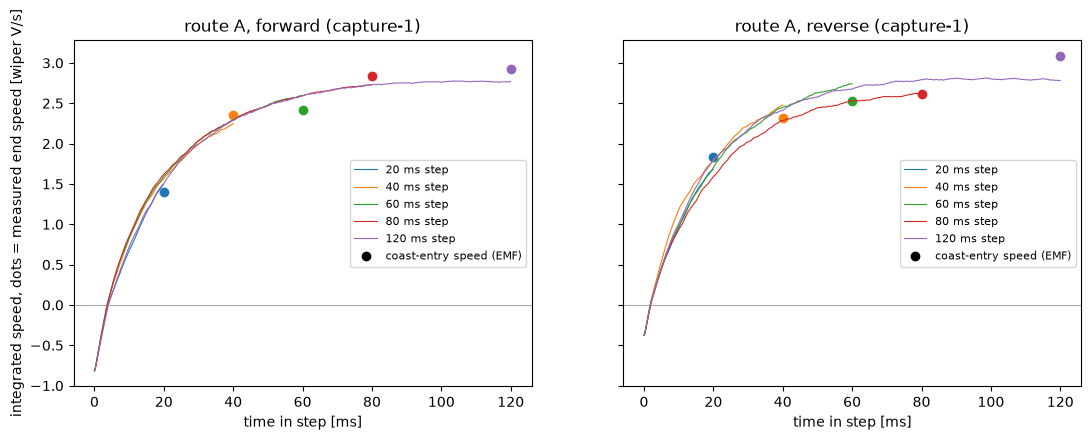

,J_i [A per wiper V/s2],omega_0 forward [wiper V/s],omega_0 reverse [wiper V/s],rms residual [wiper V/s],J_i forward only,J_i reverse only
capture-1,0.00103,-0.81725,-0.37509,0.16706,0.00091,0.00119
capture-2,0.00098,-0.96665,-1.10299,0.11576,0.00114,0.00088
capture-3,0.00100,-0.83770,-0.48625,0.12273,0.00098,0.00104
capture-4,0.00101,-0.77067,-0.60142,0.11297,0.00113,0.00098
capture-5,0.00094,-1.01631,-1.10011,0.12400,0.00109,0.00084
mean,0.00099,-0.88172,-0.73318,0.12850,0.00105,0.00099
min,0.00094,-1.01631,-1.10299,0.11297,0.00091,0.00084
max,0.00103,-0.77067,-0.37509,0.16706,0.00114,0.00119
cv [%],3.54774,11.86193,47.14753,17.15491,9.62065,14.12867


In [8]:
def integrate(cur, w0, Ji, ic, iv):
    # Forward Euler of Ji dw/dt = i - ic sign(w) - iv w at the sample rate.
    w = np.empty(len(cur))
    x = w0
    for k in range(len(cur)):
        x = x + DT * (cur[k] - ic * np.sign(x) - iv * x) / Ji
        w[k] = x
    return w

def route_a(sub, ic, iv, current="trace", w0_from=None, dirs=(1, -1)):
    # Ji shared over the steps of `sub`, one entry speed per direction unless
    # w0_from names a column that supplies it per step.
    def per_step(x):
        Ji, w0 = x[0], {1: x[1], -1: x[2]}
        rows = []
        for _, row in sub.iterrows():
            cur = row["cur"] if current == "trace" else np.full(len(row["cur"]), row["cur"].mean())
            start = row[w0_from] if w0_from else w0[row["dir"]]
            w = integrate(cur, start, Ji, ic[row["dir"]], iv[row["dir"]])
            rows.append({"recording": row["recording"], "dir": row["dir"], "step_ms": row["step_ms"],
                         "omega_T": row["omega_T"], "omega_fit": w[-1], "travel_V": row["travel_V"],
                         "travel_fit_V": np.sum(w) * DT})
        return pd.DataFrame(rows)
    def resid(x):
        tab = per_step(x)
        return (tab["omega_fit"] - tab["omega_T"]).to_numpy()
    res = least_squares(resid, [0.0012, -2.0, -2.0], bounds=([1e-5, -20, -20], [1, 20, 20]))
    tab = per_step(res.x)
    return {"Ji": res.x[0], "w0": {1: res.x[1], -1: res.x[2]},
            "rms": np.sqrt(np.mean(res.fun ** 2)), "steps": tab}

fits_a = {}
rows = []
for name, sub in steps.groupby("recording"):
    f = route_a(sub, I_C, I_V)
    f["fwd"] = route_a(sub[sub["dir"] == 1], I_C, I_V)
    f["rev"] = route_a(sub[sub["dir"] == -1], I_C, I_V)
    fits_a[name] = f
    rows.append({"recording": name, "J_i [A per wiper V/s2]": f["Ji"],
                 "omega_0 forward [wiper V/s]": f["w0"][1], "omega_0 reverse [wiper V/s]": f["w0"][-1],
                 "rms residual [wiper V/s]": f["rms"],
                 "J_i forward only": f["fwd"]["Ji"], "J_i reverse only": f["rev"]["Ji"]})
route_a_tab = pd.DataFrame(rows).set_index("recording")
J_A = route_a_tab["J_i [A per wiper V/s2]"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
name = next(iter(fits_a))
f = fits_a[name]
for ax, d in zip(axes, (1, -1)):
    sub = steps[(steps["recording"] == name) & (steps["dir"] == d)].sort_values("step_ms")
    for _, row in sub.iterrows():
        w = integrate(row["cur"], f["w0"][d], f["Ji"], I_C[d], I_V[d])
        line, = ax.plot(np.arange(len(w)) * DT * 1e3, w, lw=0.8, label=f"{row['step_ms']} ms step")
        ax.plot(row["T_s"] * 1e3, row["omega_T"], "o", color=line.get_color(), ms=6)
    ax.plot([], [], "ko", label="coast-entry speed (EMF)")
    ax.axhline(0, color="grey", lw=0.5)
    ax.set_xlabel("time in step [ms]")
    ax.set_title(f"route A, {DIRS[d]} ({name})")
    ax.legend(fontsize=8)
axes[0].set_ylabel("integrated speed, dots = measured end speed [wiper V/s]")
plt.show()

with_summary(route_a_tab).round(5)


The per-step residuals of the shared fit, pooled over recordings:


In [9]:
resid_tab = pd.concat([f["steps"] for f in fits_a.values()])
resid_tab["residual"] = resid_tab["omega_fit"] - resid_tab["omega_T"]
resid_tab["residual_pct"] = resid_tab["residual"] / resid_tab["omega_T"] * 100
(resid_tab.assign(direction=resid_tab["dir"].map(DIRS))
    .groupby(["direction", "step_ms"])[["omega_T", "omega_fit", "residual", "residual_pct", "travel_V", "travel_fit_V"]]
    .mean().round(3))


omega_T  omega_fit  residual  residual_pct  travel_V  \
direction step_ms                                                         
forward   20         1.530      1.537     0.007         0.643     0.006   
          40         2.304      2.282    -0.022        -0.882     0.061   
          60         2.506      2.632     0.126         5.070     0.109   
          80         2.773      2.772    -0.001         0.050     0.157   
          120        2.897      2.741    -0.155        -5.339     0.256   
reverse   20         1.625      1.640     0.016         1.378     0.005   
          40         2.310      2.326     0.016         0.707     0.073   
          60         2.547      2.725     0.178         6.963     0.088   
          80         2.752      2.670    -0.082        -2.919     0.149   
          120        2.972      2.775    -0.196        -6.576     0.277   

                   travel_fit_V  
direction step_ms                
forward   20              0.012  
          40              0.053  
          60              0.104  
          80              0.161  
          120             0.268  
reverse   20              0.015  
          40              0.055  
          60              0.110  
          80              0.156  
          120             0.276

Findings:

- $J_i$ is 0.00099 A per wiper V/s$^2$ on average, 0.00094 to 0.00103
  across the five recordings, a spread of 3.5%. The repeatability holds,
  and is a little better than the 5.9% the battery run gave. The fitted
  entry speeds are -0.4 to -1.1 wiper V/s, the residual reverse motion
  from the repositioning move, and they are smaller than the -1.4 to -3.0
  of the battery run because the repositioning move itself is slower on
  USB.
- The mean is 20% below the 0.00124 of the battery run. $J_i$ is a
  mechanical constant and should not depend on the supply, so this is a
  real change and section 6 and section 7 test it. The current scale is
  the one thing the chain rebuild moved (the shunt went from 33 to
  60 mOhm), and $J_i$ is in current units, so a shunt or gain error would
  show up here first.
- The fit reproduces the ten speeds of a recording with an rms residual of
  0.11 to 0.17 wiper V/s, 4 to 6% of the measured speeds, worse in
  relative terms than the battery run's 1 to 4% because the speeds are
  half as large. The residual has a shape. The 60 ms step comes out 5 to
  7% fast in both directions and the 120 ms step 5 to 7% slow, so the
  model approaches the steady speed earlier than the mechanism does. That
  is the opposite sign from the battery run, where the model was late.
- Refitted per direction, $J_i$ is 0.00105 forward (0.00091 to 0.00114)
  and 0.00099 reverse (0.00084 to 0.00119). The two overlap, and both
  spreads are about three times the shared fit's, since each rests on five
  speeds and two parameters.

The next table tests the modeling choices. The mean-current variant
replaces the trace with its step mean. The coast-friction variant replaces
the drive-side line with the coast friction of section 5.1 scaled by
$J_i$ itself, $i_c = J_i a$ and $i_v = J_i b$, which makes route A
independent of the duty grid. The pot variant fixes the entry speed of
every step at the slope of the pot over its first 5 ms.

In [10]:
def route_a_coast(sub, a, b):
    # Friction from the coast fit, scaled by the Ji being fitted.
    def resid(x):
        Ji, w0 = x[0], {1: x[1], -1: x[2]}
        return np.array([integrate(row["cur"], w0[row["dir"]], Ji, Ji * a, Ji * b)[-1] - row["omega_T"]
                         for _, row in sub.iterrows()])
    res = least_squares(resid, [0.0012, -2.0, -2.0], bounds=([1e-5, -20, -20], [1, 20, 20]))
    return {"Ji": res.x[0], "rms": np.sqrt(np.mean(res.fun ** 2))}

variants = {"measured current, entry speed fitted (route A)": {n: f for n, f in fits_a.items()}}
variants["step-mean current, entry speed fitted"] = {
    n: route_a(sub, I_C, I_V, current="mean") for n, sub in steps.groupby("recording")}
variants["measured current, coast friction scaled by J_i"] = {
    n: route_a_coast(sub, A_COAST.mean(), B_COAST.mean()) for n, sub in steps.groupby("recording")}
variants["measured current, entry speed from the pot"] = {
    n: route_a(sub, I_C, I_V, w0_from="w0_pot") for n, sub in steps.groupby("recording")}

rows = []
for label, fs in variants.items():
    j = pd.Series({n: f["Ji"] for n, f in fs.items()})
    rows.append({"variant": label, "J_i mean": j.mean(), "min": j.min(), "max": j.max(),
                 "cv [%]": j.std() / j.mean() * 100, "vs route A [%]": (j.mean() / J_A.mean() - 1) * 100,
                 "rms residual [wiper V/s]": np.mean([f["rms"] for f in fs.values()])})
J_A_COAST = pd.Series({n: f["Ji"] for n, f in variants["measured current, coast friction scaled by J_i"].items()})
variant_tab = pd.DataFrame(rows).set_index("variant")
variant_tab.round(5)


,J_i mean,min,max,cv [%],vs route A [%],rms residual [wiper V/s]
variant,,,,,,
"measured current, entry speed fitted (route A)",0.00099,0.00094,0.00103,3.54774,0.00000,0.12850
"step-mean current, entry speed fitted",0.00131,0.00128,0.00133,1.19536,31.90084,0.09408
"measured current, coast friction scaled by J_i",0.00111,0.00110,0.00112,0.71064,11.97558,0.11368
"measured current, entry speed from the pot",0.00099,0.00094,0.00105,3.83292,0.20687,0.24283


Findings:

- The step-mean current inflates $J_i$ by 32%, because the mean spreads
  the early current peak over the whole step and the model then needs
  more inertia to end at the same speed. The residual (0.094 against
  0.129 wiper V/s) does not flag the error, since the fitted entry speeds
  absorb it. The per-sample trace is required.
- With the coast friction in place of the drive-side line, $J_i$ is
  0.00111 (0.00110 to 0.00112), 12% above route A with a 0.7% spread. The
  friction line moves the answer by 12% here against 6% on the battery
  run, because the matched-range line is noisier and its viscous term
  further from the coast fit.
- Fixing the entry speed from the pot raises the residual to 0.24 wiper
  V/s, twice the fitted value. The mean $J_i$ moves only 0.2%, because the
  pot's error averages out over the five steps of a direction, but the
  per-recording values of 0.00094 to 0.00105 with a 3.8% spread owe
  nothing to the fit quality. The entry speed still has to be fitted
  (section 7 quantifies the pot's problem).

Two model-free cross-checks follow. The first fits the five coast-entry
speeds of each recording and direction with an exponential approach,
$\omega(T) = \omega_{ss} - (\omega_{ss} - \omega_0)\,e^{-T/\tau}$, with no
current and no friction in it. Its time constant is compared with the one
the fitted constants imply. Under constant applied voltage the current
falls with speed at a rate $k_i = -di/d\omega$, read here from the current
at the end of each step against the speed at the end of each step, and
the linearized equation gives the rise time constant $\tau = J_i / (k_i +
i_v)$. The friction-only constant $J_i / i_v$, the time constant of a coast
in the viscous regime, is listed for reference.

The second is the initial-slope estimate from the 20 ms step alone,
$J_i = \int (i - i_c\,\mathrm{sign}\,\omega - i_v\,\omega)\,dt \,/\,
(\omega_T - \omega_0)$, with the friction evaluated on a straight ramp
from $\omega_0$ to $\omega_T$ and $\omega_0$ taken from the pot's first
5 ms, the only entry speed that is measured on its own.

In [11]:
def rise(T, wss, w0, tau):
    return wss - (wss - w0) * np.exp(-T / tau)

rows = []
for (name, d), sub in steps.groupby(["recording", "dir"]):
    (wss, w0, tau), _ = curve_fit(rise, sub["T_s"], sub["omega_T"], p0=[6.0, -3.0, 0.02])
    i_end = np.array([row["cur"][-40:].mean() for _, row in sub.iterrows()])
    k_i = -np.polyfit(sub["omega_T"], i_end, 1)[0]
    Ji = fits_a[name]["Ji"]
    rows.append({"recording": name, "direction": DIRS[d],
                 "omega_ss, exponential [wiper V/s]": wss, "omega_0, exponential [wiper V/s]": w0,
                 "tau, exponential [ms]": tau * 1e3,
                 "k_i = -di/domega [A per wiper V/s]": k_i,
                 "tau = J_i / (k_i + i_v) [ms]": Ji / (k_i + I_V[d]) * 1e3,
                 "J_i / i_v [ms]": Ji / I_V[d] * 1e3})
tau_tab = pd.DataFrame(rows).set_index(["recording", "direction"])
TAU_EXP = tau_tab["tau, exponential [ms]"]
with_summary(tau_tab).round(3)


omega_ss, exponential [wiper V/s]  \
recording direction                                      
capture-1 reverse                                3.638   
          forward                                2.941   
capture-2 reverse                                3.148   
          forward                                2.999   
capture-3 reverse                                3.103   
          forward                                2.911   
capture-4 reverse                                2.850   
          forward                                2.856   
capture-5 reverse                                2.875   
          forward                                2.921   
mean                                             3.024   
min                                              2.850   
max                                              3.638   
cv [%]                                           7.879   

                     omega_0, exponential [wiper V/s]  tau, exponential [ms]  \
recording direction                                                            
capture-1 reverse                               1.444                 91.269   
          forward                              -0.271                 26.679   
capture-2 reverse                               0.474                 43.032   
          forward                               0.514                 34.185   
capture-3 reverse                               0.594                 33.363   
          forward                               0.184                 29.498   
capture-4 reverse                              -0.110                 22.349   
          forward                              -0.087                 24.568   
capture-5 reverse                              -0.236                 24.525   
          forward                               0.236                 28.107   
mean                                            0.274                 35.758   
min                                            -0.271                 22.349   
max                                             1.444                 91.269   
cv [%]                                        188.859                 57.116   

                     k_i = -di/domega [A per wiper V/s]  \
recording direction                                       
capture-1 reverse                                 0.039   
          forward                                 0.031   
capture-2 reverse                                 0.026   
          forward                                 0.029   
capture-3 reverse                                 0.041   
          forward                                 0.047   
capture-4 reverse                                 0.039   
          forward                                 0.041   
capture-5 reverse                                 0.041   
          forward                                 0.046   
mean                                              0.038   
min                                               0.026   
max                                               0.047   
cv [%]                                           18.181   

                     tau = J_i / (k_i + i_v) [ms]  J_i / i_v [ms]  
recording direction                                                
capture-1 reverse                          22.679         168.895  
          forward                          26.554         134.354  
capture-2 reverse                          30.359         159.841  
          forward                          26.306         127.151  
capture-3 reverse                          21.419         163.782  
          forward                          18.284         130.286  
capture-4 reverse                          22.195         164.338  
          forward                          20.554         130.729  
capture-5 reverse                          20.134         153.547  
          forward                          17.565         122.145  
mean                                       22.605 

In [12]:
rows = []
for _, row in steps[steps["step_ms"] == 20].iterrows():
    d = row["dir"]
    ramp = np.linspace(row["w0_pot"], row["omega_T"], len(row["cur"]))
    net = np.sum(row["cur"] - I_C[d] * np.sign(ramp) - I_V[d] * ramp) * DT
    rows.append({"recording": row["recording"], "direction": DIRS[d],
                 "omega_0, pot 5 ms [wiper V/s]": row["w0_pot"], "omega_T [wiper V/s]": row["omega_T"],
                 "net current integral [A s]": net,
                 "J_i, initial slope": net / (row["omega_T"] - row["w0_pot"])})
slope_tab = pd.DataFrame(rows).set_index(["recording", "direction"])
J_SLOPE = slope_tab["J_i, initial slope"]
with_summary(slope_tab).round(5)


omega_0, pot 5 ms [wiper V/s]  omega_T [wiper V/s]  \
recording direction                                                       
capture-1 forward                         -0.23505              1.39641   
          reverse                         -0.83143              1.83066   
capture-2 forward                         -0.16582              1.59866   
          reverse                         -1.01185              1.46270   
capture-3 forward                         -1.62641              1.52940   
          reverse                         -0.88277              1.71891   
capture-4 forward                         -0.56244              1.54003   
          reverse                          0.00406              1.63393   
capture-5 forward                         -0.56341              1.58761   
          reverse                         -0.99754              1.47842   
mean                                      -0.68727              1.57767   
min                                       -1.62641              1.39641   
max                                        0.00406              1.83066   
cv [%]                                    70.75009              8.10965   

                     net current integral [A s]  J_i, initial slope  
recording direction                                                  
capture-1 forward                       0.00233             0.00143  
          reverse                       0.00247             0.00093  
capture-2 forward                       0.00227             0.00129  
          reverse                       0.00288             0.00116  
capture-3 forward                       0.00291             0.00092  
          reverse                       0.00258             0.00099  
capture-4 forward                       0.00254             0.00121  
          reverse                       0.00211             0.00129  
capture-5 forward                       0.00243             0.00113  
          reverse                       0.00277             0.00112  
mean                                    0.00253             0.00115  
min                                     0.00211             0.00092  
max                                     0.00291             0.00143  
cv [%]                                 10.42482            14.43167

Findings:

- The exponential approach puts the steady speed at 2.85 to 3.64 wiper V/s
  and the time constant at 22.3 to 91.3 ms, 35.8 on average, with the
  entry speed as a third free parameter on five points. That is a lot
  looser than the battery run's 18 to 30 ms, and one fit (capture-1
  reverse) runs away to 91 ms on an entry speed of +1.4 wiper V/s that no
  other fit shows. With the speeds halved and the same absolute EMF
  ripple, this three-parameter fit on five points is the estimate that
  degraded most this session.
- The fitted constants imply 17.6 to 30.4 ms (22.6 on average) from
  $J_i / (k_i + i_v)$, with $k_i$ of 0.026 to 0.047 A per wiper V/s, and
  the current tails of section 5.2 read 16.3 to 18.3 ms. Those two agree
  on a rise time constant near 20 ms, the same answer the battery run
  gave, and the exponential is the one of the three I would not quote.
- The friction-only time constant $J_i / i_v$ is 0.12 to 0.17 s, about six
  times the rise constant. Under voltage drive the back-EMF, through
  $k_i$, is what sets the rise, and mechanical friction adds a sixth of
  the damping.
- The initial-slope estimate gives 0.00115 A per wiper V/s$^2$ on average
  (0.00092 to 0.00143), 16% above route A with a 14% spread, and its
  spread follows the pot-derived entry speed one to one, since the net
  current integral has a 10% spread across the ten steps. It confirms the
  order of magnitude and the sign of the entry-speed problem.

## 6. Route B, coast deceleration and the friction line

Coast decelerates the mechanism under friction alone, so by the equation
of the purpose section with $i = 0$, the coast constants of section 5.1
are the friction constants divided by the inertia, $a = i_c / J_i$ and
$b = i_v / J_i$. Each friction term therefore gives its own estimate,

$$J_i = \frac{i_c}{a}, \qquad J_i = \frac{i_v}{b},$$

with $i_c$ and $i_v$ from the drive-side line of section 5.3 (mean of the
two directions, and per direction) and $a$, $b$ from the coast fit of the
same recording. The table gives both per spin-down recording. A second
table converts the coast constants into current units with the route A
inertia, $J_i a$ and $J_i b$, and sets them beside the drive-side line.

In [13]:
ic_mean, iv_mean = np.mean(list(I_C.values())), np.mean(list(I_V.values()))
route_b_tab = pd.DataFrame({
    "a [wiper V/s2]": A_COAST, "b [1/s]": B_COAST,
    "J_i = i_c / a": ic_mean / A_COAST, "J_i = i_v / b": iv_mean / B_COAST,
    "J_i = i_c / a, forward": I_C[1] / A_COAST, "J_i = i_c / a, reverse": I_C[-1] / A_COAST,
    "J_i = i_v / b, forward": I_V[1] / B_COAST, "J_i = i_v / b, reverse": I_V[-1] / B_COAST,
})
J_B_C, J_B_V = route_b_tab["J_i = i_c / a"], route_b_tab["J_i = i_v / b"]
with_summary(route_b_tab).round(5)


,a [wiper V/s2],b [1/s],J_i = i_c / a,J_i = i_v / b,"J_i = i_c / a, forward","J_i = i_c / a, reverse","J_i = i_v / b, forward","J_i = i_v / b, reverse"
capture-1,31.77059,4.43237,0.00103,0.00156,0.00102,0.00105,0.00174,0.00138
capture-2,31.98459,4.22445,0.00103,0.00164,0.00101,0.00105,0.00182,0.00145
capture-3,30.67758,4.57680,0.00107,0.00151,0.00105,0.00109,0.00168,0.00134
capture-4,31.32804,4.37981,0.00105,0.00158,0.00103,0.00107,0.00176,0.00140
capture-5,30.98287,4.56527,0.00106,0.00151,0.00104,0.00108,0.00169,0.00134
mean,31.34873,4.43574,0.00105,0.00156,0.00103,0.00107,0.00174,0.00138
min,30.67758,4.22445,0.00103,0.00151,0.00101,0.00105,0.00168,0.00134
max,31.98459,4.57680,0.00107,0.00164,0.00105,0.00109,0.00182,0.00145
cv [%],1.72301,3.27585,1.72423,3.31988,1.72423,1.72423,3.31988,3.31988


In [14]:
coast_i = {"Coulomb [A]": J_A.mean() * A_COAST.mean(),
           "viscous [A per wiper V/s]": J_A.mean() * B_COAST.mean(),
           "Coulomb / viscous [wiper V/s]": A_COAST.mean() / B_COAST.mean()}
drive_i = {"Coulomb [A]": (I_C[1], I_C[-1], ic_mean),
           "viscous [A per wiper V/s]": (I_V[1], I_V[-1], iv_mean),
           "Coulomb / viscous [wiper V/s]": (I_C[1] / I_V[1], I_C[-1] / I_V[-1], ic_mean / iv_mean)}
pd.DataFrame([
    {"term": term, "coast, scaled by route A J_i": coast_i[term],
     "drive line, forward": drive_i[term][0], "drive line, reverse": drive_i[term][1],
     "drive line, mean": drive_i[term][2],
     "coast vs drive mean [%]": (coast_i[term] / drive_i[term][2] - 1) * 100}
    for term in coast_i
]).set_index("term").round(4)


,"coast, scaled by route A J_i","drive line, forward","drive line, reverse","drive line, mean",coast vs drive mean [%]
term,,,,,
Coulomb [A],0.0311,0.0323,0.0334,0.0329,-5.3693
viscous [A per wiper V/s],0.0044,0.0077,0.0061,0.0069,-36.2943
Coulomb / viscous [wiper V/s],7.0673,4.1983,5.4610,4.7577,48.5435


Findings:

- The Coulomb route gives $J_i$ of 0.00105 A per wiper V/s$^2$ (0.00103 to
  0.00107 across the spin-down recordings, a 1.7% spread), 6% above route
  A. Per direction it is 0.00103 forward and 0.00107 reverse, a 4%
  asymmetry where the battery run showed 25%, because the drive-side
  Coulomb term is now nearly the same in both directions.
- The viscous route gives 0.00156 (0.00151 to 0.00164), 57% above route A
  and 49% above the Coulomb route, far outside their spreads. The coast
  and the drive side still do not agree on the viscous term, and the
  disagreement is the same size it was on the battery run (it was 57%
  between the two route B variants there too). In current units the coast
  viscous term is 0.0044 A per wiper V/s against 0.0069 from the drive
  line, while the Coulomb terms agree within 6%. The ratio $a / b$ of 7.07
  wiper V/s against $i_c / i_v$ of 4.76 says the same thing, and the sign
  has flipped. On the battery the coast ratio sat above the drive ratio,
  and it still does, but the gap closed from a factor of 1.6 to 1.5.
- Route B is the weaker measurement by construction. It is a quotient of
  two fitted constants, and on this dataset the drive-side line carries a
  10 to 15% per-recording spread over the narrow matched range, while the
  coast fit carries 1.7 to 3.3%. Route A uses the friction line only as a
  correction to the current, and section 5.3 showed that swapping the line
  for the coast friction moves it by 12%.
- What is and is not independent. Route A and the Coulomb variant of
  route B share the drive-side line as input, so their 6% agreement tests
  the coast fit's $a$ against the step data, with the line in common. The
  coast-friction variant of route A (0.00111) uses the coast fit in place
  of the line and agrees with the Coulomb variant of route B within 6%,
  with the coast fit in common and the line dropped. No pair of estimates
  here is free of shared input, and the one input that moves an estimate
  by more than 10% is still the viscous term.
- *Hypothesis (not tested here): the drive-side viscous term is inflated
  by an electrical contribution to the steady drive current that grows
  with speed, which notebook 04 raises from the shape of its own line.
  Under that reading the coast $b$ is the mechanical viscous friction,
  $J_i b$ its value in current units, and the viscous route B is the one
  estimate here that should be set aside.*

## 7. Agreement and repeatability

The table collects every estimate of $J_i$ with its spread across
recordings and its difference from route A. The pairwise differences
follow, then the verdict, then the comparison of the two speed signals
that decides which route works.

In [15]:
def summary(label, s, note):
    return {"estimate": label, "J_i mean [A per wiper V/s2]": s.mean(), "min": s.min(), "max": s.max(),
            "cv [%]": s.std() / s.mean() * 100, "recordings": len(s),
            "vs route A [%]": (s.mean() / J_A.mean() - 1) * 100, "inputs": note}

estimates = pd.DataFrame([
    summary("route A, rise curve", J_A, "steps, drive-side friction line"),
    summary("route A, coast friction variant", J_A_COAST, "steps, coast fit"),
    summary("initial slope, 20 ms step", J_SLOPE, "20 ms steps, pot entry speed, drive-side line"),
    summary("route B, Coulomb, i_c / a", J_B_C, "coast fit a, drive-side line"),
    summary("route B, viscous, i_v / b", J_B_V, "coast fit b, drive-side line"),
]).set_index("estimate")
pd.set_option("display.max_colwidth", 60)
estimates.round(5)


,J_i mean [A per wiper V/s2],min,max,cv [%],recordings,vs route A [%],inputs
estimate,,,,,,,
"route A, rise curve",0.00099,0.00094,0.00103,3.54774,5,0.00000,"steps, drive-side friction line"
"route A, coast friction variant",0.00111,0.00110,0.00112,0.71064,5,11.97558,"steps, coast fit"
"initial slope, 20 ms step",0.00115,0.00092,0.00143,14.43167,10,15.57596,"20 ms steps, pot entry speed, drive-side line"
"route B, Coulomb, i_c / a",0.00105,0.00103,0.00107,1.72423,5,5.69911,"coast fit a, drive-side line"
"route B, viscous, i_v / b",0.00156,0.00151,0.00164,3.31988,5,57.10854,"coast fit b, drive-side line"


In [16]:
names = estimates.index.tolist()
means = estimates["J_i mean [A per wiper V/s2]"]
pairs = pd.DataFrame([[(means[r] / means[c] - 1) * 100 for c in names] for r in names],
                     index=names, columns=names)
pairs.round(1)


,"route A, rise curve","route A, coast friction variant","initial slope, 20 ms step","route B, Coulomb, i_c / a","route B, viscous, i_v / b"
"route A, rise curve",0.0,-10.7,-13.5,-5.4,-36.3
"route A, coast friction variant",12.0,0.0,-3.1,5.9,-28.7
"initial slope, 20 ms step",15.6,3.2,0.0,9.3,-26.4
"route B, Coulomb, i_c / a",5.7,-5.6,-8.5,0.0,-32.7
"route B, viscous, i_v / b",57.1,40.3,35.9,48.6,0.0


Verdict:

- Route A stands as the inertia measurement of this notebook, $J_i =
  0.00099$ A per wiper V/s$^2$ with a 3.5% spread across five recordings.
  The repeatability that the coast-entry EMF speed axis bought is intact.
  Every estimate here has a spread of 4% or less except the initial slope,
  which rests on the pot.
- The Coulomb route B (0.00105) sits 6% above it, the coast-friction
  variant of route A (0.00111) 12% above, and the initial-slope check 16%
  above. Route A is now the lowest of the four rather than the middle one,
  and the four span 16% instead of the battery run's 13%. That is the
  agreement this notebook can claim.
- The viscous route B (0.00156) is again the one estimate outside that
  bracket, 57% above route A, and section 6 traces it to a viscous term
  that the coast and the drive side measure differently. It is reported
  and set aside.
- The whole set has moved down by about 20% from the battery session
  (route A 0.00099 against 0.00124, Coulomb route B 0.00105 against
  0.00116). $J_i$ carries the current scale, and the chain rebuild changed
  the shunt from 33 to 60 mOhm, so a shunt or gain error is the first
  place I would look. The measurement does not settle that on its own.
- The implied mechanical rise time constant under 30% drive is near 20 ms
  by the current tails and the linearized estimate, and the friction-only
  constant $J_i / i_v$ is about 0.15 s.

The last table shows why the coast EMF is the speed signal for this
measurement. The rise curve needs the speed at the end of a 20 or 40 ms
step. From the pot that speed is a slope over the last 5 ms of the step,
and the acceleration over the step is the difference of two such slopes
divided by the step length. From the EMF it is a 1 ms average with the
pot ripple absent. The table compares the spread of each across the ten
steps of a length (five recordings, two directions).

In [17]:
def cv(s):
    return np.std(s) / abs(np.mean(s)) * 100

rows = []
for ms in (20, 40):
    sub = steps[steps["step_ms"] == ms]
    acc_pot = (sub["wT_pot"] - sub["w0_pot"]) / sub["T_s"]
    acc_quad = np.array([2 * np.polyfit(np.arange(len(row["pos"])) * DT, row["pos"], 2)[0]
                         for _, row in sub.iterrows()])
    w0_fit = np.array([fits_a[row["recording"]]["w0"][row["dir"]] for _, row in sub.iterrows()])
    acc_emf = (sub["omega_T"] - w0_fit) / sub["T_s"]
    for label, s in [("end speed, pot last 5 ms [wiper V/s]", sub["wT_pot"]),
                     ("end speed, EMF [wiper V/s]", sub["omega_T"]),
                     ("entry speed, pot first 5 ms [wiper V/s]", sub["w0_pot"]),
                     ("acceleration, pot end minus start [wiper V/s2]", acc_pot),
                     ("acceleration, pot quadratic fit [wiper V/s2]", acc_quad),
                     ("acceleration, EMF end minus fitted entry [wiper V/s2]", acc_emf)]:
        rows.append({"quantity": label, "step": f"{ms} ms", "mean": np.mean(s), "cv [%]": cv(s)})
signal_tab = pd.DataFrame(rows).set_index(["quantity", "step"]).unstack("step")
signal_tab.round(2)


mean         cv [%]  \
step                                                    20 ms   40 ms  20 ms   
quantity                                                                       
acceleration, EMF end minus fitted entry [wiper V/s2]  119.26   77.86   6.92   
acceleration, pot end minus start [wiper V/s2]          79.84  106.35  37.62   
acceleration, pot quadratic fit [wiper V/s2]           114.92  106.80  47.10   
end speed, EMF [wiper V/s]                               1.58    2.31   7.69   
end speed, pot last 5 ms [wiper V/s]                     0.91    3.50  52.09   
entry speed, pot first 5 ms [wiper V/s]                 -0.69   -0.75  67.12   

                                                               
step                                                    40 ms  
quantity                                                       
acceleration, EMF end minus fitted entry [wiper V/s2]    7.02  
acceleration, pot end minus start [wiper V/s2]         128.01  
acceleration, pot quadratic fit [wiper V/s2]            98.37  
end speed, EMF [wiper V/s]                               3.57  
end speed, pot last 5 ms [wiper V/s]                   152.56  
entry speed, pot first 5 ms [wiper V/s]                 40.77

Findings:

- The pot's end speed of the 20 ms step scatters by 52% across the ten
  steps and by 153% at 40 ms, and the accelerations built from it by 38 to
  128%, whether from end minus start or from a quadratic through the whole
  step. The EMF's end speed scatters by 7.7% at 20 ms and 3.6% at 40 ms.
  The pot is worse than it was on the battery (42% at 20 ms there) and the
  EMF is worse too at 40 ms (0.7% there). Both follow from the speeds
  being half as large against an unchanged ripple.
- The accelerations from the EMF end speed and the fitted entry speed
  scatter by 7%, and most of that is the entry speed, which the fit
  absorbs once per direction. The pot cannot supply that entry speed
  either. Its first 5 ms scatter by 67% at 20 ms and 41% at 40 ms.
- The pot's ripple, 20 to 30% of speed at a period of 0.1 to 0.2 wiper V
  of travel (notebook 01, section 6.1), is the whole of the difference.
  A 20 ms step travels 0.006 wiper V, a small fraction of one ripple
  period, so a slope over 5 ms of it reads the ripple, and the EMF does
  not carry it.

## 8. Limitations and open issues

- **The board is a hacked rig.** The bus telemetry stream couples into the
  current amplifier output on this board (section 1). It is flat at rest
  on this firmware build, but a few counts is a few milliamps, and the
  friction line of section 5.3 lives on 30 to 70 mA. Route A takes the
  line only as a correction, so a few milliamps there is well under its
  12% sensitivity, but route B is a quotient of the line and would carry
  it directly. This is a limitation of this board, not something I code
  around.
- **$J_i$ moved 20% between sessions.** The supply and the measurement
  chain both changed, and $J_i$ should depend on neither. The current
  scale is the suspect (section 7). A shunt measured with a four-wire
  meter, or a rise curve at a second supply on the same chain, would
  settle it.
- **One unit, one supply, one duty.** All numbers describe this one servo
  on a laptop USB port, and the rise curve was taken at 30% duty only. A
  rise curve at a second duty would test whether $J_i$ is independent of
  the current level, as it must be if the current-to-torque relation is
  linear.
- **$J_i$ is $J / K_t$.** The inertia in SI units needs the torque
  constant and, for the motor shaft, the gear ratio. Neither is measured
  here. $J_i$ is the constant the mechanical equation in current units
  needs, and that equation is what the control loop sees.
- **The friction line is an input, and a narrower one.** Route A and route
  B both take the drive-side line, recomputed here with the method of
  notebook 04, and section 6 shows the coast and the drive side disagree
  on the viscous term. The matched range is 5.0 wiper V/s on this supply
  against 10.5 on the battery, so the line rests on fewer duty points and
  its per-recording spread doubled. Route A's sensitivity to the choice is
  12%.
- **The entry speed is fitted.** Every step starts from residual reverse
  motion, and its speed is a free parameter per direction and recording,
  on the premise that the repositioning move repeats. The fitted values
  are -0.4 to -1.1 wiper V/s, and a step from rest would remove the
  parameter.
- **The residual has a shape, and it flipped sign.** The shared fit comes
  out 5 to 7% fast at 60 ms and 5 to 7% slow at 120 ms, where the battery
  run was late rather than early. The friction line is the term most
  likely to carry it.
- **The exponential rise fit degraded.** Three parameters on five points
  at half the speed gives 22 to 91 ms (section 5.3), so I quote the rise
  time constant from the current tails and the linearized estimate
  instead.
- **Forward Euler at 50 us.** The integration step equals the sample
  period and the shortest time scale in the equation is the 20 ms rise,
  so the discretization error is below 0.3%. The current between samples
  is taken as the sample value.
- **Voltages are nominal-referenced.** Every voltage and current scales
  with the true VDD of this unit, so $J_i$ scales with it as well.

## 9. What the next notebooks use from here

- The inertia in current units, $J_i = 0.00099$ A per wiper V/s$^2$
  (0.00094 to 0.00103 across recordings), as the constant of the
  mechanical equation $J_i\,\dot\omega = i - i_c\,\mathrm{sign}\,\omega -
  i_v\,\omega$, with the open question of the 20% shift from the battery
  session attached to it.
- The EMF-to-speed slope $k_e = 0.276$ V per wiper V/s from this session's
  spin-down coasts, and the coast friction $a = 31.3$ wiper V/s$^2$, $b =
  4.44$ 1/s by the terminal route.
- The rise time constant under voltage drive, near 20 ms at 30% duty, and
  the current-speed lever $k_i$ of about 0.04 A per wiper V/s at 30% duty,
  for the electrical side in notebook 03's terms.
- The finding that the coast and drive-side viscous terms differ by a
  factor of 1.6 in current units while the Coulomb terms agree within 6%,
  as an input to the reconciliation of friction and back-EMF across
  notebooks 03 and 04.
- The rule that speed at the end of a short step is read from the coast
  EMF, that the first three coast samples are not usable, and that the
  entry speed of a step that starts in motion is a fitted parameter, since
  the pot's ripple defeats both.